<a href="https://colab.research.google.com/github/sete50/navaraj/blob/main/bigdatavisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ['PYSPARK_PYTHON']='python'

In [ ]:
# import Sparksession
from pyspark.sql import SparkSession


In [ ]:
spark = SparkSession.builder \
    .appName("Students performance Analysis") \
    .getOrCreate()

In [ ]:
# Read csv file and display few rows
df = spark.read.csv("/content/StudentPerformanceFactors.csv", header=True, inferSchema=True)
df.show(5)

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

In [ ]:
# Print the schema to see data types
df.printSchema()

root
 |-- Hours_Studied: integer (nullable = true)
 |-- Attendance: integer (nullable = true)
 |-- Parental_Involvement: string (nullable = true)
 |-- Access_to_Resources: string (nullable = true)
 |-- Extracurricular_Activities: string (nullable = true)
 |-- Sleep_Hours: integer (nullable = true)
 |-- Previous_Scores: integer (nullable = true)
 |-- Motivation_Level: string (nullable = true)
 |-- Internet_Access: string (nullable = true)
 |-- Tutoring_Sessions: integer (nullable = true)
 |-- Family_Income: string (nullable = true)
 |-- Teacher_Quality: string (nullable = true)
 |-- School_Type: string (nullable = true)
 |-- Peer_Influence: string (nullable = true)
 |-- Physical_Activity: integer (nullable = true)
 |-- Learning_Disabilities: string (nullable = true)
 |-- Parental_Education_Level: string (nullable = true)
 |-- Distance_from_Home: string (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Exam_Score: integer (nullable = true)



In [ ]:
df.describe().show()

+-------+------------------+------------------+--------------------+-------------------+--------------------------+------------------+------------------+----------------+---------------+------------------+-------------+---------------+-----------+--------------+------------------+---------------------+------------------------+------------------+------+------------------+
|summary|     Hours_Studied|        Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|       Sleep_Hours|   Previous_Scores|Motivation_Level|Internet_Access| Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence| Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|        Exam_Score|
+-------+------------------+------------------+--------------------+-------------------+--------------------------+------------------+------------------+----------------+---------------+------------------+-------------+---------------+-----------+-----

In [ ]:
from pyspark.sql.functions import col, count, when

# Count null in each column
null_counts = df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|Hours_Studied|Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|Sleep_Hours|Previous_Scores|Motivation_Level|Internet_Access|Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence|Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|Exam_Score|
+-------------+----------+--------------------+-------------------+--------------------------+-----------+---------------+----------------+---------------+-----------------+-------------+---------------+-----------+--------------+-----------------+---------------------+------------------------+------------------+------+----------+
|

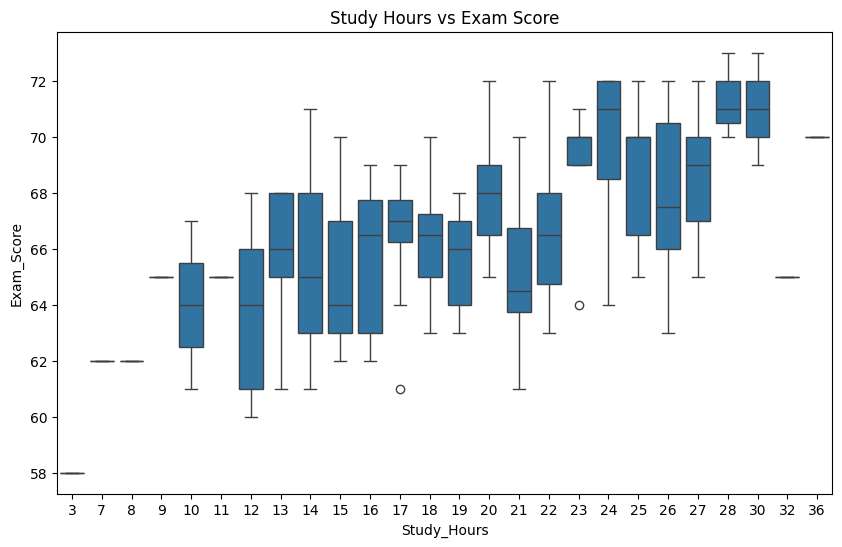

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


#  Sample 2% of the data
sampled_pd_clean = df.select("Hours_Studied", "Exam_Score").sample(False, 0.02).toPandas()

# 2. Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Hours_Studied', y='Exam_Score', data=sampled_pd_clean)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Study_Hours")
plt.ylabel("Exam_Score")
plt.show()

In [ ]:
correlation= df.corr("Hours_Studied", "Exam_Score")
print(correlation)

0.44545495407528174


In [ ]:
correlation1= df.corr("Attendance", "Exam_Score")
print(correlation1)

0.5810718633120632


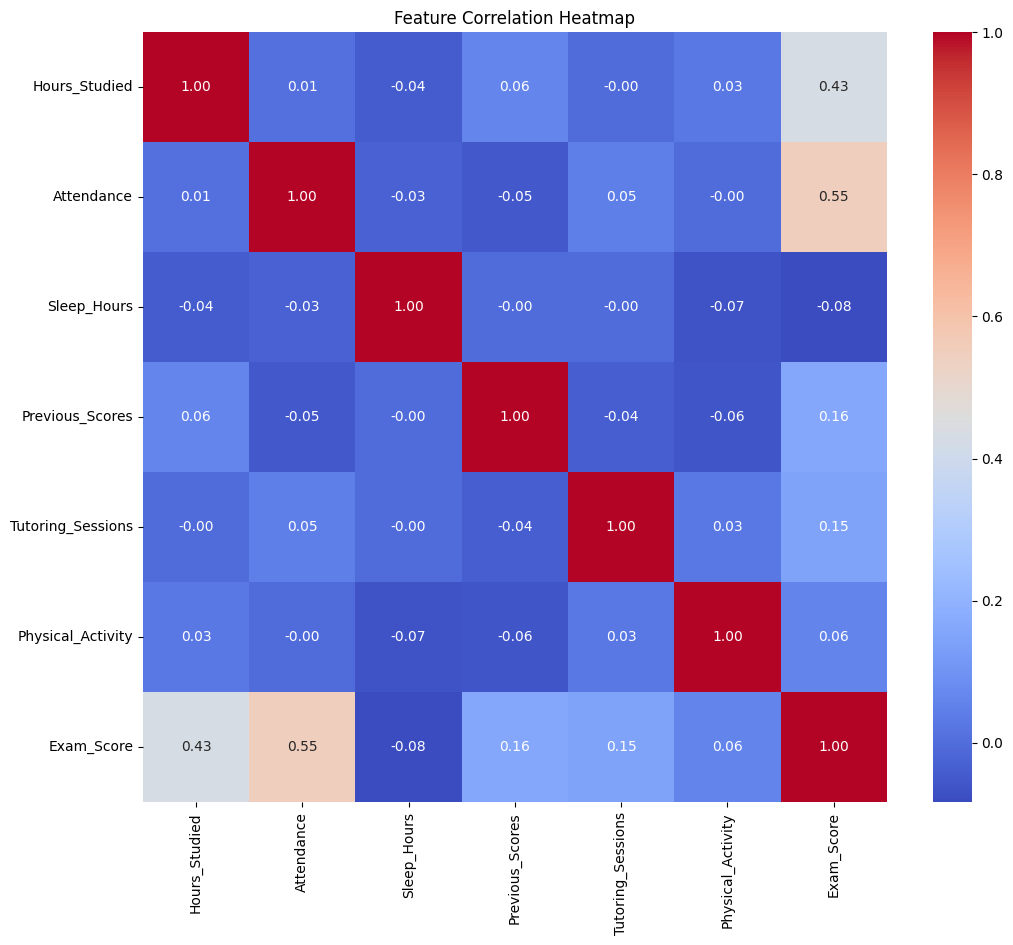

In [ ]:
# import build in libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.types import IntegerType, FloatType

# Identify numeric columns
numeric_cols = [col_name for col_name, col_type in df.dtypes if col_type == 'int' or col_type == 'double']


#  10% Sampling
sampled_df_pd = df.select(numeric_cols).sample(False, 0.1, seed=42).toPandas()

# Calculate the correlation matrix
corr_matrix = sampled_df_pd.corr()

# Plotting the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

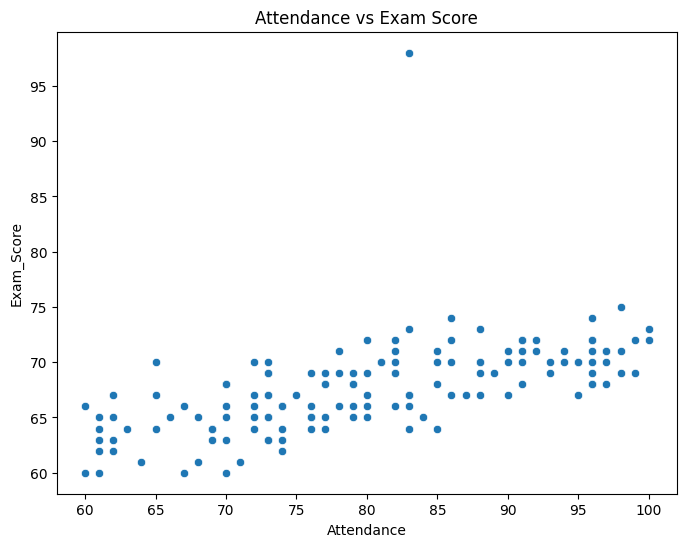

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#  2% Sampling
sampled_df_pd = df.sample(False, 0.02, seed=42).toPandas()
# Plotting the scatter plot
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(x= "Attendance", y= "Exam_Score", data= sampled_df_pd )
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam_Score")
plt.show()



In [ ]:
import pandas as pd

# Read the entire CSV file
full_df_pd = pd.read_csv("/content/StudentPerformanceFactors.csv")

# Extract columns into pandas DataFrames
attendence_pd = full_df_pd[['Attendance']]
study_pd = full_df_pd[['Hours_Studied']]
score_pd = full_df_pd[['Exam_Score']]
parent_pd = full_df_pd[['Parental_Involvement']]
gender_pd = full_df_pd[['Gender']]
access_pd = full_df_pd[['Internet_Access']]
extra_pd = full_df_pd[['Extracurricular_Activities']]

# Display the head
print("Attendance DataFrame head:")
print(attendence_pd.head())


Attendance DataFrame head:
   Attendance
0          84
1          64
2          98
3          89
4          92


In [ ]:
# Create Dataframe
attendance = spark.createDataFrame(attendence_pd)
hours_studied = spark.createDataFrame(study_pd)
score = spark.createDataFrame(score_pd)
parent = spark.createDataFrame(parent_pd)
gender = spark.createDataFrame(gender_pd)
access = spark.createDataFrame(access_pd)
extra = spark.createDataFrame(extra_pd)

In [ ]:
parent.show(5)
parent.printSchema()

+--------------------+
|Parental_Involvement|
+--------------------+
|                 Low|
|                 Low|
|              Medium|
|                 Low|
|              Medium|
+--------------------+
only showing top 5 rows
root
 |-- Parental_Involvement: string (nullable = true)



In [ ]:
import pandas as pd
df_clean = df.na.drop()
#To create temporary view for SQL
attendance.createOrReplaceTempView("attendance")
hours_studied.createOrReplaceTempView("hours_studied")
score.createOrReplaceTempView("exam_score")
parent.createOrReplaceTempView("parental_involvement")
gender.createOrReplaceTempView("gender_only")
access.createOrReplaceTempView("internet_access")
extra.createOrReplaceTempView("extracurricular_activities")
df_clean.createOrReplaceTempView("student_performance")

In [ ]:
# Average Score by Gender
query2 = """ SELECT Gender, Avg(Exam_Score) as Average_Score FROM student_performance GROUP BY Gender """
result2 = spark.sql(query2)
result2.show()

+------+-----------------+
|Gender|    Average_Score|
+------+-----------------+
|Female|67.27472118959108|
|  Male|67.23562906724511|
+------+-----------------+



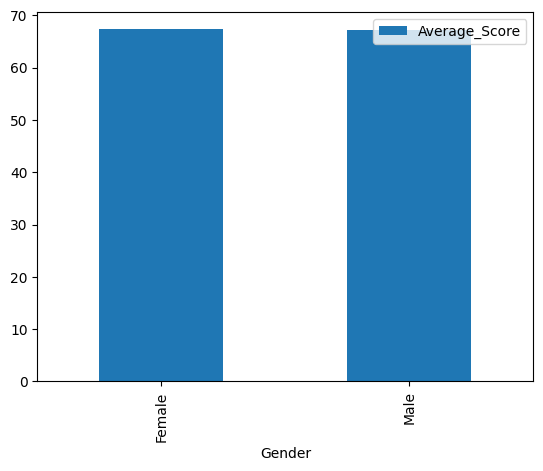

In [ ]:
import matplotlib.pyplot as plt
df = result2.toPandas()
df.plot(kind = 'bar', x = 'Gender', y = 'Average_Score')
plt.show()


In [ ]:
df_clean.describe().show()

+-------+-----------------+------------------+--------------------+-------------------+--------------------------+------------------+-----------------+----------------+---------------+------------------+-------------+---------------+-----------+--------------+------------------+---------------------+------------------------+------------------+------+-----------------+
|summary|    Hours_Studied|        Attendance|Parental_Involvement|Access_to_Resources|Extracurricular_Activities|       Sleep_Hours|  Previous_Scores|Motivation_Level|Internet_Access| Tutoring_Sessions|Family_Income|Teacher_Quality|School_Type|Peer_Influence| Physical_Activity|Learning_Disabilities|Parental_Education_Level|Distance_from_Home|Gender|       Exam_Score|
+-------+-----------------+------------------+--------------------+-------------------+--------------------------+------------------+-----------------+----------------+---------------+------------------+-------------+---------------+-----------+-------------